# Data Cleaning Project

## Oasis Infobyte — Data Analytics Level 1, Task 3

### Objective
The objective of this project is to clean a messy retail dataset and transform it into a reliable, analysis-ready dataset. Each cleaning decision will be documented clearly.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/OIBSIP/online_retail_real_world.csv")
df.head()

,OrderID,CustomerID,ProductName,Brand,Raw_Weight,Country,OrderDate,UnitPrice
0,REC-861088,6120,Perly,Perly,100 g,"Morocco,United States",2024-02-22,13.18
1,REC-900952,12550,Prince Goût Chocolat,LU,300 g,"Algeria,Belgium,France,French Polynesia,German...",2024-11-13,1.50
2,REC-595965,6705,Excellence Noir Prodigieux 90% Cacao,"Lindt EXCELLENCE,Lindt",100g,"Argelia,Austria,Bélgica,Bulgaria,Canadá,Repúbl...",2025-02-02,12.99
3,REC-942653,8645,Tonik,عربي,22 g,Maroc,2024-12-11,14.82
4,REC-885998,14430,Sésame,Gerblé,230g,"Belgium, Bulgaria, France, en:switzerland",2025-08-21,18.40


In [ ]:
# Save the original dataset for before vs after comparision
df_before = df.copy()

print("Dataset Shape:", df.shape)

print("\n Column Names:")
print(df.columns.tolist())

print("\n Data Types:")
print(df.dtypes)

print("\n Missing Value Per Column:")
print(df.isnull().sum())

print("\n Duplicate Rows:", df.duplicated().sum())

print("\n Descriptive Statistics:")
display(df.describe(include="all"))


Dataset Shape: (3000, 8)

 Column Names:
['OrderID', 'CustomerID', 'ProductName', 'Brand', 'Raw_Weight', 'Country', 'OrderDate', 'UnitPrice']

 Data Types:
OrderID         object
CustomerID       int64
ProductName     object
Brand           object
Raw_Weight      object
Country         object
OrderDate       object
UnitPrice      float64
dtype: object

 Missing Value Per Column:
OrderID          0
CustomerID       0
ProductName     96
Brand          335
Raw_Weight     512
Country          0
OrderDate        0
UnitPrice      385
dtype: int64

 Duplicate Rows: 0

 Descriptive Statistics:


,OrderID,CustomerID,ProductName,Brand,Raw_Weight,Country,OrderDate,UnitPrice
count,3000,3000.000000,2904,2665,2488,3000,3000,2615.000000
unique,2992,NaN,2726,1110,729,1013,718,NaN
top,REC-189159,NaN,Dark Chocolate,Gerblé,100 g,France,2024-08-31,NaN
freq,2,NaN,5,55,159,662,11,NaN
mean,NaN,9989.842333,NaN,NaN,NaN,NaN,NaN,12.992417
std,NaN,2871.959873,NaN,NaN,NaN,NaN,NaN,6.963856
min,NaN,5011.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,7454.750000,NaN,NaN,NaN,NaN,NaN,6.985000
50%,NaN,10066.000000,NaN,NaN,NaN,NaN,NaN,13.160000
75%,NaN,12527.250000,NaN,NaN,NaN,NaN,NaN,18.960000


## Initial Data Quality Report

The dataset contains 3,000 records and 8 columns. Several data-quality issues were identified before cleaning.

Missing values were found in ProductName (96), Brand (335), Raw_Weight (512), and UnitPrice (385). No fully duplicate rows were found. However, there are only 2,992 unique OrderID values, indicating that 8 repeated order IDs require investigation.

OrderDate is currently stored as text and will be converted to datetime format. ProductName, Brand, Raw_Weight, and Country will also be checked for inconsistent formatting.

In [ ]:
missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100 ). round(2)
})
display(missing_report)

# Inspect repeated order Ids
print("Repeated Order Ids:", df["OrderID"].duplicated().sum())

display(
    df[df["OrderID"].duplicated(keep=False)]
    .sort_values("OrderID")
)

# Inspect the most common va;ues in key text columns
for column in ["ProductName","Brand","Raw_Weight","Country"]:
  print("f\nTop Values in {column}:")
  display(df[column].value_counts(dropna=False).head(10))

,Missing Values,Missing Percentage
OrderID,0,0.00
CustomerID,0,0.00
ProductName,96,3.20
Brand,335,11.17
Raw_Weight,512,17.07
Country,0,0.00
OrderDate,0,0.00
UnitPrice,385,12.83


Repeated Order Ids: 8


,OrderID,CustomerID,ProductName,Brand,Raw_Weight,Country,OrderDate,UnitPrice
944,REC-127088,12111,Toetilla Chips Nature,Carrefour,200 g,"Belgium,France,Morocco, Italie, Espagne, Polog...",2024-12-04,1.48
2724,REC-127088,5338,NaN,"belVita, belVita Breakfast",NaN,"France, Romania, en:bulgaria",2025-11-21,NaN
1311,REC-133930,12583,Tartelettes framboise,Bonne Maman,135 g,"Belgique,France,Allemagne,Suisse,Royaume-Uni",2024-04-27,19.72
1535,REC-133930,12702,Galleta de mantequilla con tableta de chocolat...,Carrefour BIO,150 g,"France,Italy,Poland,Romania,Spain,Switzerland,...",2025-10-06,6.06
574,REC-189159,13071,RASPBERRY WHOLEGRAIN OAT BARS,stoats,4 x 42 g,en:gb,2024-04-22,8.56
1942,REC-189159,13365,Mini tartelettes,NaN,250 g,France,2025-12-15,13.77
1320,REC-388577,12823,Doritos Tangy Cheese,"Doritos,Walkers",180g,United Kingdom,2025-03-01,19.30
2492,REC-388577,13112,Grain Free Tortilla Chips,Siete,5 oz (142 g),"France, World, en:united-states",2024-04-23,15.58
1129,REC-660334,12862,Création Crème Brûlée,Lindt,150 g,France,2025-11-24,20.24
1314,REC-660334,5314,Pains au chocolat x 8,"Marque Repère, Épi d'Or",360 g,France,2024-03-05,21.88


f
Top Values in {column}:


,count
ProductName,
NaN,96
Cream Crackers,5
Dark Chocolate,5
Petit beurre,5
Chocolat noir,4
Ferrero Rocher,4
Lentil Chips,4
Dark chocolate,4
Raffaello,4


...

,count
Brand,
NaN,335
Gerblé,55
Hacendado,50
Carrefour,41
Lindt,40
Gullón,40
Bjorg,32
LU,31
St Michel,28


f
Top Values in {column}:


,count
Raw_Weight,
NaN,512
100 g,159
200 g,136
150 g,110
300 g,84
100g,62
250 g,59
125 g,49
150g,42


f
Top Values in {column}:


,count
Country,
France,662
United Kingdom,150
en:gb,101
"France, en:united-kingdom",54
en:United Kingdom,52
Morocco,45
"France,United Kingdom",44
España,40
en:Morocco,37


## Data Cleaning Decisions

Repeated OrderID values will be removed because each OrderID should represent one unique order.

Missing ProductName and Brand values will be labelled as “Unknown” rather than guessed.

Raw_Weight will be standardised into a numeric Weight_g column. Missing weights will be filled with the median weight because the median is less affected by unusual values.

Missing UnitPrice values will also be filled with the median unit price. Country names and text fields will be standardised for consistent formatting.

In [ ]:
from IPython.core import error
# Create a Clean Wroking Copy
df_clean = df.copy()

# 1. Remove repeated Order IDs
rows_before_duplicates =len(df_clean)
df_clean = df_clean.drop_duplicates(subset="OrderID", keep="first").copy()
rows_removed = rows_before_duplicates - len(df_clean)

# 2. Clean text columns and handle missing categorical values
df_clean["ProductName"] = (
    df_clean["ProductName"]
    .astype("string")
    .str.strip()
    .fillna("Unknown")
)

df_clean["Brand"] = (
    df_clean["Brand"]
    .astype("string")
    .str.strip()
    .fillna("Unknown")
)

# 3. Standardise country names
df_clean["Country"] = (
    df_clean["Country"]
    .astype("string")
    .str.replace("en:","", regex=False)
    .str.replace("-","", regex=False)
    .str.replace(r"\s*,\s*",",", regex=True)
    .str.strip()
    .str.title()
)

country_replacements = {
    r"\bGb\b": "United Kingdom",
    r"\bUs\b": "United States",
    "España": "Spain",
    "Maroc": "Morocco",
    "Bélgica": "Belgium"
}

for old, new in country_replacements.items():
  df_clean['Country'] = df_clean["Country"].str.replace(old, new, regex=True)

# 4. Convert raw weight into numeric grams
weight_text = (
    df_clean["Raw_Weight"]
    .astype("string")
    .str.lower()
    .str.replace(r"\s+","", regex=True)
)

df_clean["weight_g"] = pd.to_numeric(
    weight_text.str.extract(r"(\d+(?:\.\d+)?)")[0],
    errors="coerce"
)

# Convert Kilograms to grams if any exists
df_clean.loc[weight_text.str.contains("kg",na=False),"weight_g"] *= 1000

# Fill missing weights using the median
df_clean["weight_g"] = df_clean["weight_g"].fillna(df_clean["weight_g"].median())

# 5. Fill missing unit prices using median
df_clean["UnitPrice"] = df_clean["UnitPrice"].fillna(df_clean["UnitPrice"].median())

# 6. Convert OrderDate to datetime
df_clean["OrderDate"] = pd.to_datetime(df_clean["OrderDate"],errors="coerce")

print("Rows removed due to repeated Order IDs:", rows_removed)
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

df_clean.head()


Rows removed due to repeated Order IDs: 8

Missing values after cleaning:
OrderID          0
CustomerID       0
ProductName      0
Brand            0
Raw_Weight     510
Country          0
OrderDate        0
UnitPrice        0
weight_g         0
dtype: int64


,OrderID,CustomerID,ProductName,Brand,Raw_Weight,Country,OrderDate,UnitPrice,weight_g
0,REC-861088,6120,Perly,Perly,100 g,"Morocco,United States",2024-02-22,13.18,100.0
1,REC-900952,12550,Prince Goût Chocolat,LU,300 g,"Algeria,Belgium,France,French Polynesia,German...",2024-11-13,1.50,300.0
2,REC-595965,6705,Excellence Noir Prodigieux 90% Cacao,"Lindt EXCELLENCE,Lindt",100g,"Argelia,Austria,Belgium,Bulgaria,Canadá,Repúbl...",2025-02-02,12.99,100.0
3,REC-942653,8645,Tonik,عربي,22 g,Morocco,2024-12-11,14.82,22.0
4,REC-885998,14430,Sésame,Gerblé,230g,"Belgium,Bulgaria,France,Switzerland",2025-08-21,18.40,230.0


### Cleaning Progress

Eight repeated OrderID records were removed. Missing ProductName and Brand values were replaced with “Unknown”.

Raw_Weight values were converted into a new numeric weight_g column, with missing weights filled using the median. Missing UnitPrice values were also filled using the median. Country labels were standardised, and OrderDate was converted to datetime format.

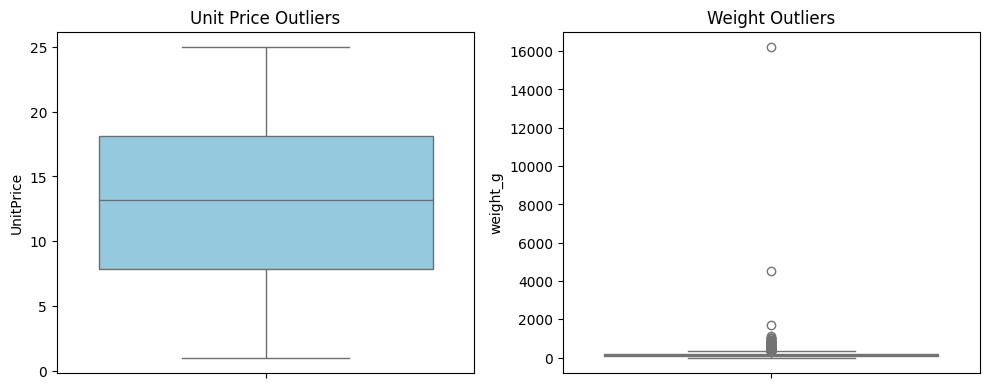

In [ ]:
# Outlier detection using thr IQR method
outlier_summary = []

for column in ["UnitPrice","weight_g"]:
  q1 = df_clean[column].quantile(0.25)
  q3 = df_clean[column].quantile(0.75)
  iqr = q3 - q1

  lower_limit = q1 - 1.5 * iqr
  upper_limit = q3 + 1.5 * iqr

  outlier_count = (
      (df_clean[column] < lower_limit) |
      (df_clean[column] > upper_limit)
  ).sum()

  outlier_summary.append({
      "Column" : column,
      "Lower Limit" : round(lower_limit,2),
      "Upper Limit" : round(upper_limit,2),
      "Outlier Count" : outlier_count
  })

outlier_report = pd.DataFrame(outlier_summary)
outlier_report

plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_clean["UnitPrice"],color="skyblue")
plt.title("Unit Price Outliers")

plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean["weight_g"],color="lightgreen")
plt.title("Weight Outliers")

plt.tight_layout()
plt.show()


## Outlier Detection and Treatment

The IQR method found no significant outliers in UnitPrice. However, several extreme values were found in weight_g. Since these values were much larger than typical retail food-product weights, they were capped at the IQR upper limit rather than removed. This preserves all records while reducing the influence of extreme values.

In [ ]:
# Cap outliers in weight_g using the IQR upper limit
q1 = df_clean["weight_g"].quantile(0.25)
q3 = df_clean["weight_g"].quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

weight_outlier_count = (
      (df_clean["weight_g"] < lower_limit) |
      (df_clean["weight_g"] > upper_limit)
).sum()

df_clean["weight_g"] = df_clean["weight_g"].clip(
    lower =lower_limit,
    upper = upper_limit
)

print("Weight outliers capped:", weight_outlier_count)
print("Upper limit used:",round(upper_limit, 2))


Weight outliers capped: 251
Upper limit used: 350.0


## Final Data Preparation

The original Raw_Weight column contained inconsistent text formats and missing values. It was replaced with the cleaned numeric Weight_g column.

OrderID and CustomerID were converted to string data types because they are identifiers. OrderDate was converted to datetime format, while UnitPrice and Weight_g were retained as numeric values.

The final cleaned dataset contains no missing values, no repeated OrderID values, and consistent data types.

In [28]:
# Create the final cleaned dataset
df_final = df_clean.drop(columns=["Raw_Weight"].copy())

# Rename clean weight column
df_final = df_final.rename(columns={"weight_g":"weight_g"})

# Correct final data types
df_final["OrderID"] = df_final["OrderID"].astype("string")
df_final["CustomerID"] = df_final["CustomerID"].astype("string")
df_final["ProductName"] = df_final["ProductName"].astype("string")
df_final["Brand"] = df_final["Brand"].astype("string")
df_final["Country"] = df_final["Country"].astype("string")
df_final["OrderDate"] = pd.to_datetime(df_final["OrderDate"])
df_final["UnitPrice"] = df_final["UnitPrice"].astype(float)
df_final["weight_g"] = df_final["weight_g"].astype(float)

# Before vs After Cleaning Summary
before_after_summary = pd.DataFrame({
    "Metric": [
        "Row Count",
        "Total Missing Values",
        "Exact Duplicate Rows",
        "Repeated Order IDs",
        "OrderDate Data Type",
        "CustomerID Data Type",
        "Weight Format"
    ],
    "Before Cleaning": [
        len(df_before),
        df_before.isnull().sum().sum(),
        df_before.duplicated().sum(),
        df_before["OrderID"].duplicated().sum(),
        str(df_before["OrderDate"].dtype),
        str(df_before["CustomerID"].dtype),
        "Text with inconsistent formats"
    ],
    "After Cleaning": [
        len(df_final),
        df_final.isnull().sum().sum(),
        df_final.duplicated().sum(),
        df_final["OrderID"].duplicated().sum(),
        str(df_final["OrderDate"].dtype),
        str(df_final["CustomerID"].dtype),
        "Numeric grams (weight_g)"
    ]

})

display(before_after_summary)

print("\n Final Missing Values:")
print(df_final.isnull().sum())

print("\n Final Data Types:")
print(df_final.dtypes)

# save cleanned dataset to Google Drive
output_path = "/content/drive/MyDrive/OIBSIP/cleaned_online_retail_data.csv"
df_final.to_csv(output_path,index=False)

print(f"\n Cleanned dataset saved successfully: {output_path}")

df_final.head()

,Metric,Before Cleaning,After Cleaning
0,Row Count,3000,2992
1,Total Missing Values,1328,0
2,Exact Duplicate Rows,0,0
3,Repeated Order IDs,8,0
4,OrderDate Data Type,object,datetime64[ns]
5,CustomerID Data Type,int64,string
6,Weight Format,Text with inconsistent formats,Numeric grams (weight_g)



 Final Missing Values:
OrderID        0
CustomerID     0
ProductName    0
Brand          0
Country        0
OrderDate      0
UnitPrice      0
weight_g       0
dtype: int64

 Final Data Types:
OrderID        string[python]
CustomerID     string[python]
ProductName    string[python]
Brand          string[python]
Country        string[python]
OrderDate      datetime64[ns]
UnitPrice             float64
weight_g              float64
dtype: object

 Cleanned dataset saved successfully: /content/drive/MyDrive/OIBSIP/cleaned_online_retail_data.csv


,OrderID,CustomerID,ProductName,Brand,Country,OrderDate,UnitPrice,weight_g
0,REC-861088,6120,Perly,Perly,"Morocco,United States",2024-02-22,13.18,100.0
1,REC-900952,12550,Prince Goût Chocolat,LU,"Algeria,Belgium,France,French Polynesia,German...",2024-11-13,1.50,300.0
2,REC-595965,6705,Excellence Noir Prodigieux 90% Cacao,"Lindt EXCELLENCE,Lindt","Argelia,Austria,Belgium,Bulgaria,Canadá,Repúbl...",2025-02-02,12.99,100.0
3,REC-942653,8645,Tonik,عربي,Morocco,2024-12-11,14.82,22.0
4,REC-885998,14430,Sésame,Gerblé,"Belgium,Bulgaria,France,Switzerland",2025-08-21,18.40,230.0


# Conclusion

This project transformed a messy retail dataset into a clean, analysis-ready dataset.

The cleaning process removed 8 repeated OrderID records, resolved 1,328 missing values, standardised text and country formatting, converted dates and identifiers to appropriate data types, and created a numeric weight_g column.

Outlier detection using the IQR method identified 251 extreme weight values. These values were capped at 350 grams to reduce their impact while preserving all valid records.

The final dataset contains 2,992 records, no missing values, no repeated OrderID values, and consistent data types. It is now ready for further analysis or machine-learning use.